In [13]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pathlib as Path
pd.set_option('display.max_columns', None)

In [14]:
# Set a professional visual style for all your upcoming charts
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams['figure.figsize'] = (10, 6)

# Load the meticulously engineered regular match data
# (We leave the super overs behind for now to keep our baselines pure)
df = pd.read_csv('../data/processed/ipl_features_regular.csv')

print(f"Dataset loaded successfully with {len(df)} rows")

Dataset loaded successfully with 289498 rows


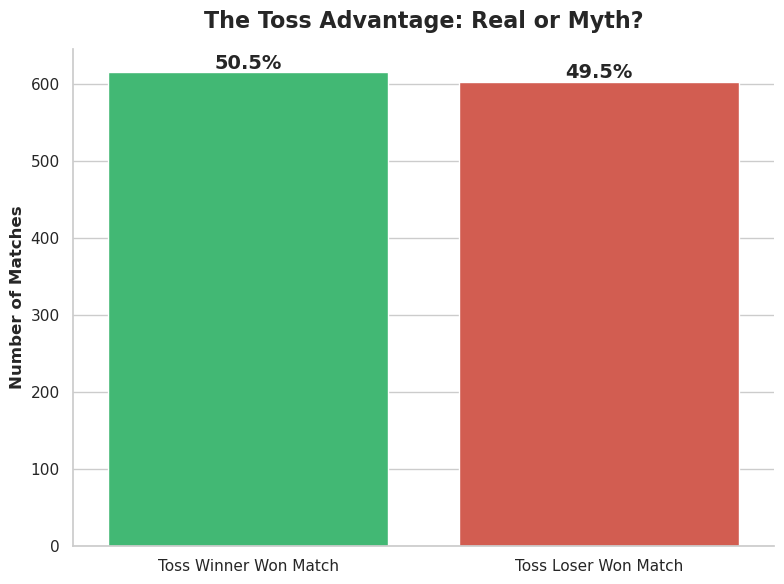

In [15]:
# --- STEP 1: Convert to Match-Level Data ---
# Drop duplicates so we only have exactly 1 row for every unique match_id
match_df = df.drop_duplicates(subset=['match_id']).copy()

# --- STEP 2: Calculate the Toss Impact ---
# Create a simple True/False column if the toss winner also won the match
match_df['toss_winner_won_match'] = match_df['toss_winner'] == match_df['winner']

# Count the exact number of matches
toss_counts = match_df['toss_winner_won_match'].value_counts()
total_matches = len(match_df)

# Calculate the percentages for our chart labels
win_pct = (toss_counts[True] / total_matches) * 100
loss_pct = (toss_counts[False] / total_matches) * 100

# --- STEP 3: Build the Visualization ---
plt.figure(figsize=(8, 6))

# Create the bars using Seaborn
# (Using a nice green for the 'advantage' and red for 'no advantage')
ax = sns.barplot(
    x=['Toss Winner Won Match', 'Toss Loser Won Match'], 
    y=[toss_counts[True], toss_counts[False]],
    palette=['#2ecc71', '#e74c3c'],
    hue=['Toss Winner Won Match', 'Toss Loser Won Match'] # Modern Seaborn requires hue for palettes
)

# Add title and axis labels
plt.title('The Toss Advantage: Real or Myth?', fontsize=16, fontweight='bold', pad=15)
plt.ylabel('Number of Matches', fontsize=12, fontweight='bold')

# Annotate the bars with the exact percentage
ax.text(0, toss_counts[True] + 5, f"{win_pct:.1f}%", ha='center', fontsize=14, fontweight='bold')
ax.text(1, toss_counts[False] + 5, f"{loss_pct:.1f}%", ha='center', fontsize=14, fontweight='bold')

# Strip the top and right borders for a cleaner, modern look
sns.despine()

plt.tight_layout()
plt.show()

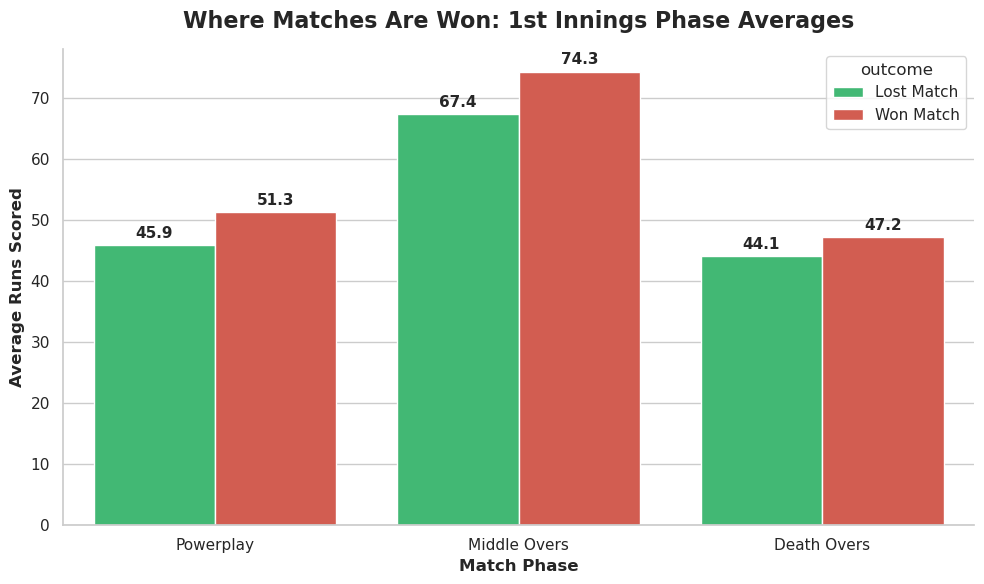

In [16]:
# --- STEP 1: Isolate 1st Innings & Determine Outcome ---
# Keep only 1st innings to ensure a fair comparison of full 20-over strategies
first_innings = df.copy()

# Create a clear flag: Did the team setting the target actually win the game?
first_innings['outcome'] = np.where(
    first_innings['batting_team'] == first_innings['winner'], 
    'Won Match', 
    'Lost Match'
)

# --- STEP 2: Calculate Runs per Phase for Every Match ---
# Group by match, phase, and outcome to sum the runs
phase_totals = first_innings.groupby(
    ['match_id', 'phase', 'outcome']
)['runs_total'].sum().reset_index()


# --- STEP 3: Build the Grouped Bar Chart ---
plt.figure(figsize=(10, 6))

# Seaborn's barplot automatically calculates the mean (average) of our phase_totals
ax = sns.barplot(
    data=phase_totals,
    x='phase',
    y='runs_total',
    hue='outcome',
    order=['Powerplay', 'Middle Overs', 'Death Overs'], # Force logical chronological order
    palette=['#2ecc71', '#e74c3c'], # Green for win, Red for loss
    errorbar=None # Removes the error lines for a cleaner look
)

# Add titles and labels
plt.title('Where Matches Are Won: 1st Innings Phase Averages', fontsize=16, fontweight='bold', pad=15)
plt.xlabel('Match Phase', fontsize=12, fontweight='bold')
plt.ylabel('Average Runs Scored', fontsize=12, fontweight='bold')

# Add the exact numbers on top of the bars
for container in ax.containers:
    ax.bar_label(container, fmt='%.1f', padding=3, fontsize=11, fontweight='bold')

# Clean up the borders
sns.despine()

plt.tight_layout()
plt.show()

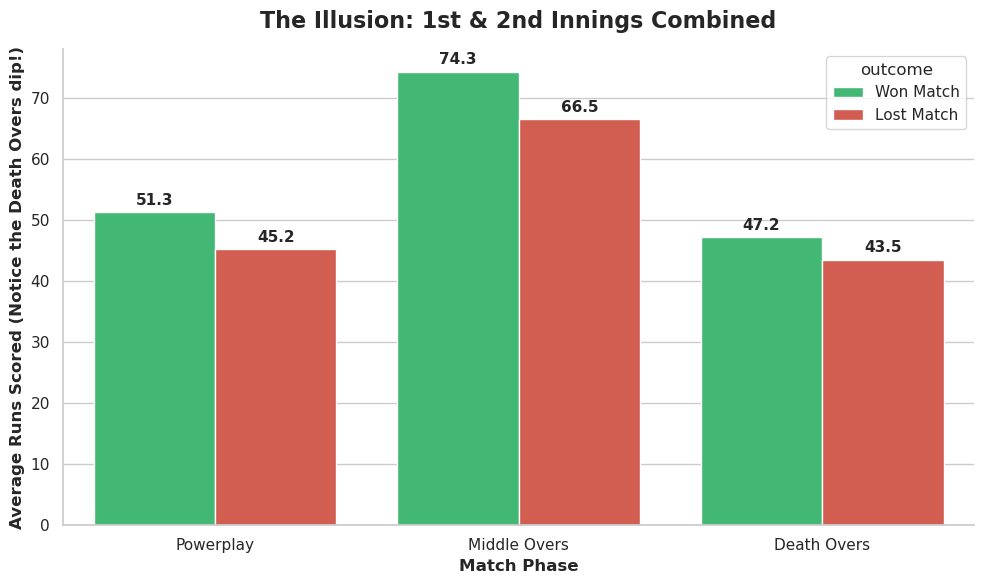

In [17]:
# --- STEP 1: Use BOTH Innings ---
# We keep both 1st and 2nd innings
all_innings = df[df['innings'] <= 2].copy()

all_innings['outcome'] = np.where(
    all_innings['batting_team'] == all_innings['winner'], 
    'Won Match', 
    'Lost Match'
)

# --- STEP 2: Calculate Runs ---
# Notice we added 'innings' to the groupby so we don't accidentally merge a team's 1st and 2nd innings!
phase_totals_skewed = all_innings.groupby(
    ['match_id', 'innings', 'phase', 'outcome']
)['runs_total'].sum().reset_index()

# --- STEP 3: Build the Skewed Chart ---
plt.figure(figsize=(10, 6))

ax = sns.barplot(
    data=phase_totals_skewed,
    x='phase',
    y='runs_total',
    hue='outcome',
    order=['Powerplay', 'Middle Overs', 'Death Overs'], 
    palette=['#2ecc71', '#e74c3c'],
    errorbar=None 
)

plt.title('The Illusion: 1st & 2nd Innings Combined', fontsize=16, fontweight='bold', pad=15)
plt.xlabel('Match Phase', fontsize=12, fontweight='bold')
plt.ylabel('Average Runs Scored (Notice the Death Overs dip!)', fontsize=12, fontweight='bold')

for container in ax.containers:
    ax.bar_label(container, fmt='%.1f', padding=3, fontsize=11, fontweight='bold')

sns.despine()
plt.tight_layout()
plt.show()

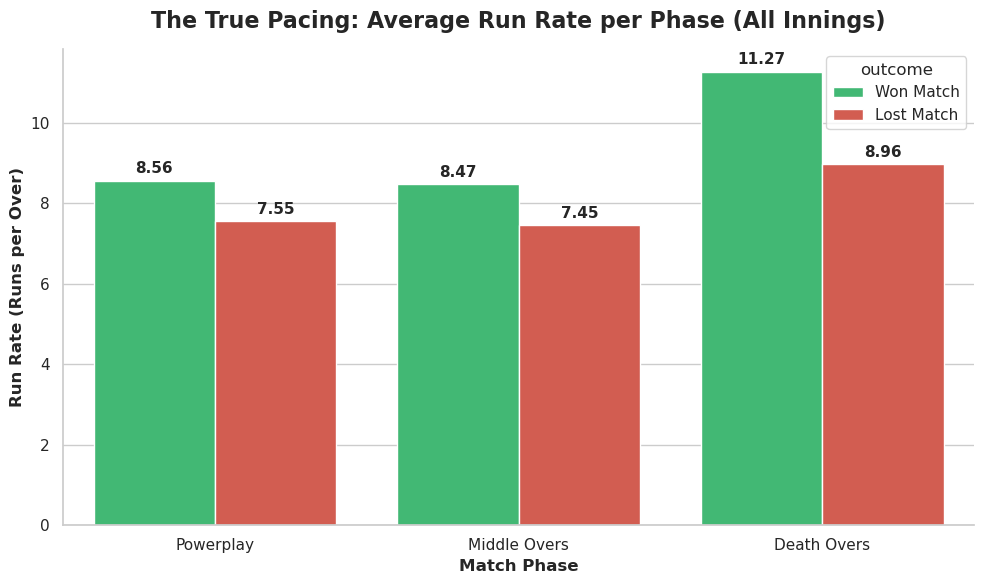

In [18]:
# --- STEP 1: Prep Both Innings ---
# We can safely use the whole regular dataset now!
all_innings = df.copy()

# Flag whether the batting team won or lost the match
all_innings['outcome'] = np.where(
    all_innings['batting_team'] == all_innings['winner'], 
    'Won Match', 
    'Lost Match'
)

# --- STEP 2: Calculate Runs & Legal Balls per Phase ---
# Group by match, innings, phase, and outcome
phase_stats = all_innings.groupby(['match_id', 'innings', 'phase', 'outcome']).agg(
    total_runs=('runs_total', 'sum'),
    legal_balls=('is_legal_delivery', 'sum')
).reset_index()

# Filter out any weird anomalies where 0 legal balls were bowled to avoid division by zero errors
phase_stats = phase_stats[phase_stats['legal_balls'] > 0].copy()

# --- STEP 3: The Run Rate Math ---
# Formula: (Runs / Balls) * 6
phase_stats['run_rate'] = (phase_stats['total_runs'] / phase_stats['legal_balls']) * 6


# --- STEP 4: Build the True Representation Chart ---
plt.figure(figsize=(10, 6))

# Seaborn will now average out the 'run_rate' column
ax = sns.barplot(
    data=phase_stats,
    x='phase',
    y='run_rate',
    hue='outcome',
    order=['Powerplay', 'Middle Overs', 'Death Overs'], 
    palette=['#2ecc71', '#e74c3c'],
    errorbar=None 
)

plt.title('The True Pacing: Average Run Rate per Phase (All Innings)', fontsize=16, fontweight='bold', pad=15)
plt.xlabel('Match Phase', fontsize=12, fontweight='bold')
plt.ylabel('Run Rate (Runs per Over)', fontsize=12, fontweight='bold')

# Add the labels
for container in ax.containers:
    ax.bar_label(container, fmt='%.2f', padding=3, fontsize=11, fontweight='bold')

sns.despine()
plt.tight_layout()
plt.show()

/tmp/ipykernel_44136/3764818000.py:42: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=top_batters, x='total_runs', y='batter', ax=axes[0], palette='viridis')
/tmp/ipykernel_44136/3764818000.py:55: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=top_bowlers, x='total_wickets', y='bowler', ax=axes[1], palette='magma')


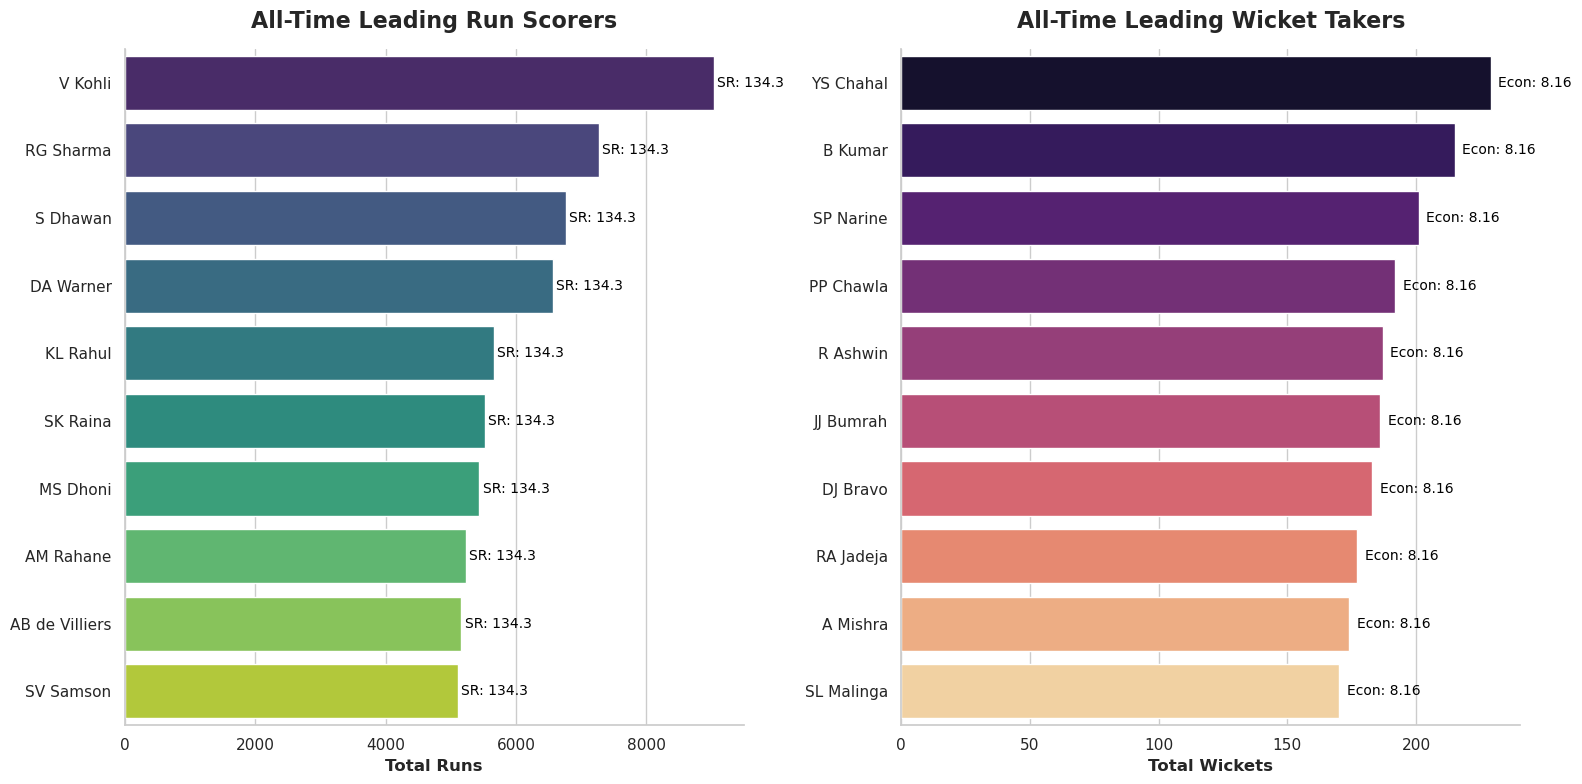

In [19]:
# --- STEP 1: Calculate Batter Stats ---
# Group by batter and calculate total runs and total balls faced
batter_stats = all_innings.groupby('batter').agg(
    total_runs=('runs_batter', 'sum'),
    balls_faced=('is_legal_delivery', 'sum') 
).reset_index()

# Calculate Strike Rate (Runs per 100 balls)
batter_stats['strike_rate'] = (batter_stats['total_runs'] / batter_stats['balls_faced']) * 100

# Get the Top 10 Run Scorers
top_batters = batter_stats.nlargest(10, 'total_runs')


# --- STEP 2: Calculate Bowler Stats ---
# Define exactly which dismissals belong to the bowler
bowler_dismissals = ['caught', 'bowled', 'lbw', 'stumped', 'caught and bowled', 'hit wicket']

# Create a temporary column just for this calculation
all_innings['is_bowler_wicket'] = all_innings['wicket_kind'].isin(bowler_dismissals).astype(int)

# Group by bowler and calculate total wickets and total legal balls bowled
bowler_stats = all_innings.groupby('bowler').agg(
    total_wickets=('is_bowler_wicket', 'sum'),
    balls_bowled=('is_legal_delivery', 'sum'),
    runs_conceded=('runs_total', 'sum') # Using runs_total as a baseline for economy
).reset_index()

# Calculate Economy Rate (Runs conceded per 6 balls)
# Filter out 0 balls bowled to avoid division errors
bowler_stats = bowler_stats[bowler_stats['balls_bowled'] > 0]
bowler_stats['economy'] = (bowler_stats['runs_conceded'] / bowler_stats['balls_bowled']) * 6

# Get the Top 10 Wicket Takers
top_bowlers = bowler_stats.nlargest(10, 'total_wickets')


# --- STEP 3: Build the Side-by-Side Visualization ---
fig, axes = plt.subplots(1, 2, figsize=(16, 8))

# Chart 1: Top Batters (Left Side)
sns.barplot(data=top_batters, x='total_runs', y='batter', ax=axes[0], palette='viridis')
axes[0].set_title('All-Time Leading Run Scorers', fontsize=16, fontweight='bold', pad=15)
axes[0].set_xlabel('Total Runs', fontsize=12, fontweight='bold')
axes[0].set_ylabel('')

# Add Strike Rate text to the end of each batter's bar
for container in axes[0].containers:
    for i, bar in enumerate(container):
        sr = top_batters.iloc[i]['strike_rate']
        axes[0].text(bar.get_width() + 50, bar.get_y() + bar.get_height()/2, 
                     f"SR: {sr:.1f}", va='center', fontsize=10, color='black')

# Chart 2: Top Bowlers (Right Side)
sns.barplot(data=top_bowlers, x='total_wickets', y='bowler', ax=axes[1], palette='magma')
axes[1].set_title('All-Time Leading Wicket Takers', fontsize=16, fontweight='bold', pad=15)
axes[1].set_xlabel('Total Wickets', fontsize=12, fontweight='bold')
axes[1].set_ylabel('')

# Add Economy Rate text to the end of each bowler's bar
for container in axes[1].containers:
    for i, bar in enumerate(container):
        econ = top_bowlers.iloc[i]['economy']
        axes[1].text(bar.get_width() + 3, bar.get_y() + bar.get_height()/2, 
                     f"Econ: {econ:.2f}", va='center', fontsize=10, color='black')

# Clean up layout
sns.despine()
plt.tight_layout()
plt.show()

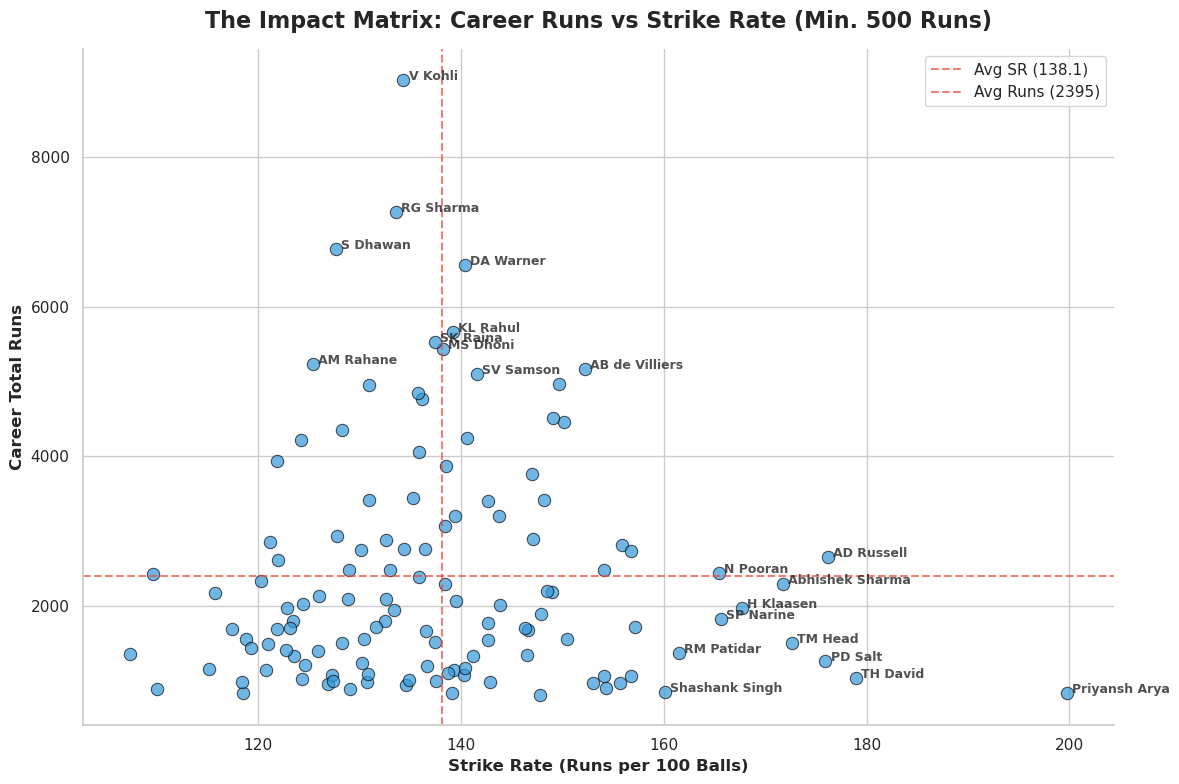

In [31]:
# --- STEP 1: Calculate Career Stats ---
batter_impact = all_innings.groupby('batter').agg(
    total_runs=('runs_batter', 'sum'),
    balls_faced=('is_legal_delivery', 'sum')
).reset_index()

# --- STEP 2: The Crucial Volume Filter ---
# Filter out the noise by requiring a minimum of 500 career runs
impact_players = batter_impact[batter_impact['total_runs'] >= 800].copy()

# Calculate Strike Rate for this elite group
impact_players['strike_rate'] = (impact_players['total_runs'] / impact_players['balls_faced']) * 100

# --- STEP 3: Calculate Quadrant Averages ---
avg_runs = impact_players['total_runs'].mean()
avg_sr = impact_players['strike_rate'].mean()

# --- STEP 4: Build the Impact Matrix ---
plt.figure(figsize=(12, 8))

# Draw the scatter plot
sns.scatterplot(
    data=impact_players, 
    x='strike_rate', 
    y='total_runs', 
    alpha=0.7, 
    color='#3498db', 
    edgecolor='black',
    s=80 # Size of the dots
)

# Draw the quadrant lines (averages)
plt.axvline(avg_sr, color='#e74c3c', linestyle='--', alpha=0.7, label=f'Avg SR ({avg_sr:.1f})')
plt.axhline(avg_runs, color='#e74c3c', linestyle='--', alpha=0.7, label=f'Avg Runs ({avg_runs:.0f})')

# --- STEP 5: Annotate the Elite Players ---
# Automatically write the names of players who are absolute outliers
# (You can adjust these thresholds based on who you want to highlight)
for i, row in impact_players.iterrows():
    if row['total_runs'] > 5000 or row['strike_rate'] > 160:
        plt.text(
            row['strike_rate'] + 0.5, # Nudge text slightly right
            row['total_runs'], 
            row['batter'], 
            fontsize=9, 
            fontweight='bold', 
            alpha=0.8
        )

# Add Titles and Labels
plt.title('The Impact Matrix: Career Runs vs Strike Rate (Min. 500 Runs)', fontsize=16, fontweight='bold', pad=15)
plt.xlabel('Strike Rate (Runs per 100 Balls)', fontsize=12, fontweight='bold')
plt.ylabel('Career Total Runs', fontsize=12, fontweight='bold')
plt.legend(loc='upper right')

sns.despine()
plt.tight_layout()
plt.show()

When you run this code, your scatter plot will be divided into four boxes by the red dashed lines:

    Top Right (The Elites): High volume, high strike rate. These are the absolute legends of the IPL (look for AB de Villiers here).

    Top Left (The Anchors): High volume, lower strike rate. These guys score thousands of runs but take their time doing it (often openers who play through the innings).

    Bottom Right (The Finishers): Lower volume, massive strike rate. These are your death-over specialists (look for Andre Russell or Kieron Pollard here).

    Bottom Left (The Average Performers): Players below average in both categories.